### Imports

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import networkx as nx
import matplotlib.pyplot as plt

### Project Path

In [2]:
project = Path(
    r"C:\Users\HP\Documents\python\bio informatics\final exam\ThreatGraphx"
)

### Load All Edge Files

In [3]:
cve_cwe = pd.read_csv(
    project / "data" / "processed" / "cve_cwe_edges.csv"
)

cwe_capec = pd.read_csv(
    project / "data" / "processed" / "cwe_capec_edges.csv"
)

capec_attack = pd.read_csv(
    project / "data" / "processed" / "capec_attack_edges.csv"
)

attack_mitigation = pd.read_csv(
    project / "data" / "processed" / "attack_mitigation_edges.csv"
)

software_edges = pd.read_csv(
    project / "data" / "processed" / "software_edges.csv"
)

### Merge

In [4]:
edges = pd.concat(
    [
        cve_cwe,
        cwe_capec,
        capec_attack,
        attack_mitigation,
        software_edges
    ],
    ignore_index=True
)

print(len(edges))

15573


### Relation Distribution

In [5]:
relation_counts = (
    edges["relation"]
    .value_counts()
)

relation_counts

relation
maps_to         5845
affects         4772
has_weakness    2296
mitigated_by    1448
mapped_to       1212
Name: count, dtype: int64

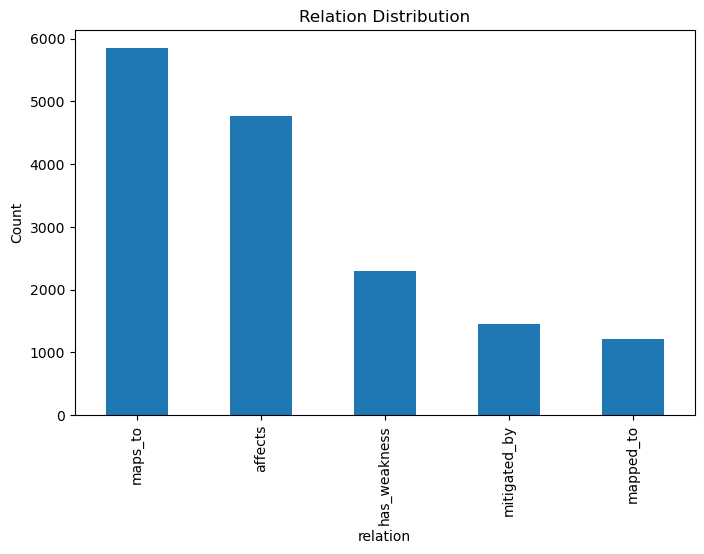

In [7]:
plt.figure(figsize=(8,5))

relation_counts.plot(kind="bar")

plt.title("Relation Distribution")

plt.ylabel("Count")

plt.show()

-------------

### Node Type Distribution

In [8]:
node_types = []

all_nodes = set(edges["source"]).union(
    set(edges["target"])
)

for node in all_nodes:

    if node.startswith("CVE"):
        node_types.append("CVE")

    elif node.startswith("CWE"):
        node_types.append("CWE")

    elif node.startswith("CAPEC"):
        node_types.append("CAPEC")

    elif node.startswith("T"):
        node_types.append("ATTACK")

    else:
        node_types.append("OTHER")

In [9]:
node_type_counts = pd.Series(
    node_types
).value_counts()

node_type_counts

OTHER     3569
CVE       2024
ATTACK     921
CAPEC      565
CWE        423
Name: count, dtype: int64

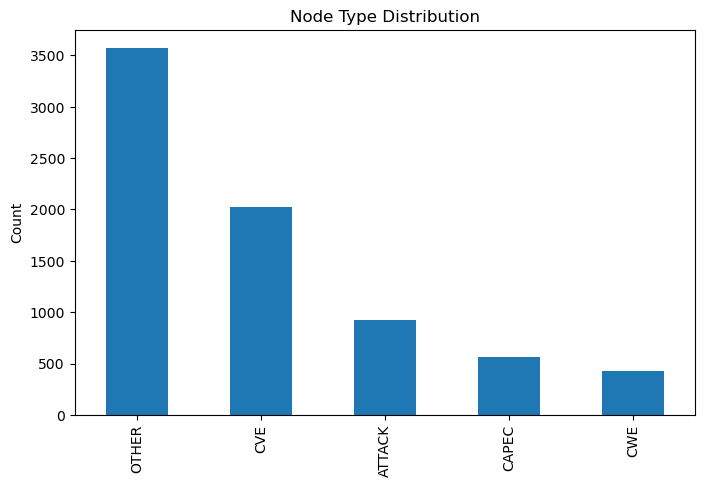

In [10]:
plt.figure(figsize=(8,5))

node_type_counts.plot(kind="bar")

plt.title("Node Type Distribution")

plt.ylabel("Count")

plt.show()

**Because Mitigation and Software are names:**
- Execution Prevention
- Apache Tomcat
- Windows 11
they will currently appear as: **OTHER**

---------

### SMALL SUBGRAPH

### Build SMALL CLEAN GRAPH

In [21]:
G = nx.DiGraph()

edges_demo = [
    ("CVE-1", "CWE-79", "has_weakness"),
    ("CWE-79", "CAPEC-63", "mapped_to"),
    ("CAPEC-63", "T1059", "maps_to"),
    ("T1059", "Execution Prevention", "mitigated_by"),
    ("CVE-1", "Apache Tomcat", "affects"),

    ("CVE-2", "CWE-89", "has_weakness"),
    ("CWE-89", "CAPEC-66", "mapped_to"),
    ("CAPEC-66", "T1190", "maps_to"),
    ("T1190", "Web Filtering", "mitigated_by"),
    ("CVE-2", "MySQL", "affects"),

    ("CVE-3", "CWE-787", "has_weakness"),
    ("CWE-787", "CAPEC-100", "mapped_to"),
    ("CAPEC-100", "T1068", "maps_to"),
    ("T1068", "Memory Protection", "mitigated_by"),
    ("CVE-3", "Windows", "affects")
]

for s, t, r in edges_demo:
    G.add_edge(s, t, relation=r)

### AUTO LAYOUT

In [22]:
pos = nx.spring_layout(G, seed=42, k=2)

### NODE COLORS

In [23]:
node_colors = []

for node in G.nodes():

    if node.startswith("CVE"):
        node_colors.append("lightcoral")

    elif node.startswith("CWE"):
        node_colors.append("orange")

    elif node.startswith("CAPEC"):
        node_colors.append("lightgreen")

    elif node.startswith("T"):
        node_colors.append("lightskyblue")

    else:
        node_colors.append("lightgray")

### PLOT - Sample

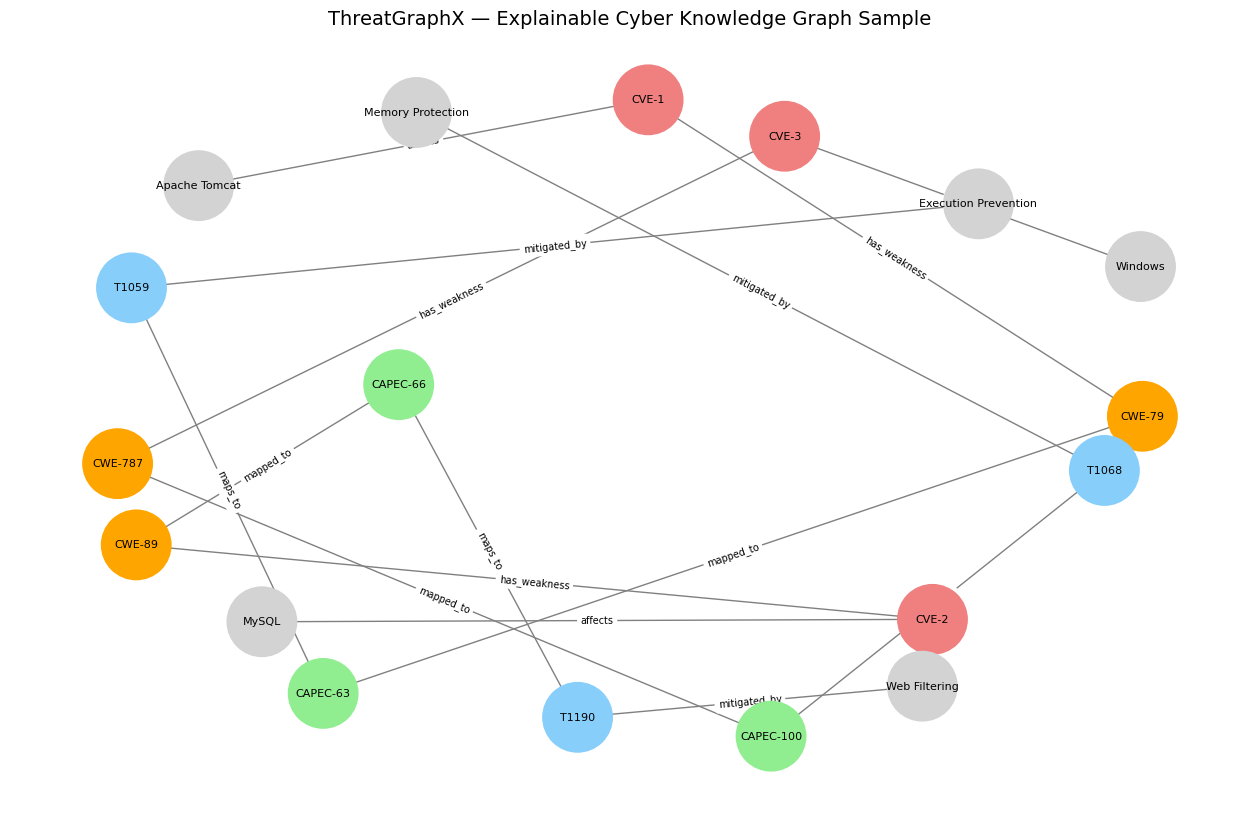

In [24]:
plt.figure(figsize=(16, 10))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2500
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    edge_color="gray"
)

edge_labels = nx.get_edge_attributes(G, "relation")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("ThreatGraphX — Explainable Cyber Knowledge Graph Sample", fontsize=14)

plt.axis("off")
plt.show()